# Evaluation & Business Insights

## Objective
1. Evaluate the best candidate models on the **held-out test set** (used for the first time here).
2. Perform threshold analysis — explore the precision/recall trade-off.
3. Conduct error analysis — understand false positives and false negatives.
4. Interpret feature importance.
5. Analyse customer/campaign patterns associated with predicted response.
6. Discuss responsible AI considerations.
7. Produce evidence-based business recommendations.

> **Important:** The test set is used **only once** in this notebook. No further model adjustments will be made after this point.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Reload Data & Rebuild All Pipelines

In [2]:
df = pd.read_csv('../data/raw/bank_marketing.csv')
df = df.drop(columns=['duration'])
df['y'] = (df['y'] == 'yes').astype(int)
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0,30,40,50,60,100],
                          labels=['<30','30-40','40-50','50-60','60+']).astype(str)
df['campaign_capped'] = df['campaign'].clip(upper=int(df['campaign'].quantile(0.95)))

X = df.drop(columns=['y'])
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val,   X_test,  y_val,  y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Test set: {X_test.shape[0]:,} rows | positive rate: {y_test.mean():.3f}")


Test set: 6,782 rows | positive rate: 0.117


In [3]:
numerical_features = ['age','balance','day_of_week','campaign','campaign_capped',
                       'pdays','previous','was_previously_contacted']
categorical_features = ['job','marital','education','default','housing','loan',
                         'contact','month','poutcome','age_group']

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
cat_pipe = Pipeline([('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, numerical_features),
                                   ('cat', cat_pipe, categorical_features)], remainder='drop')

models = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
        ('m', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('pre', preprocessor),
        ('m', RandomForestClassifier(n_estimators=200, max_depth=10,
                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('pre', preprocessor),
        ('m', GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE))]),
}

# Fit all on train
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"Trained: {name}")


Trained: Logistic Regression


Trained: Random Forest


Trained: Gradient Boosting


## 2. ROC Curves & PR Curves — Test Set

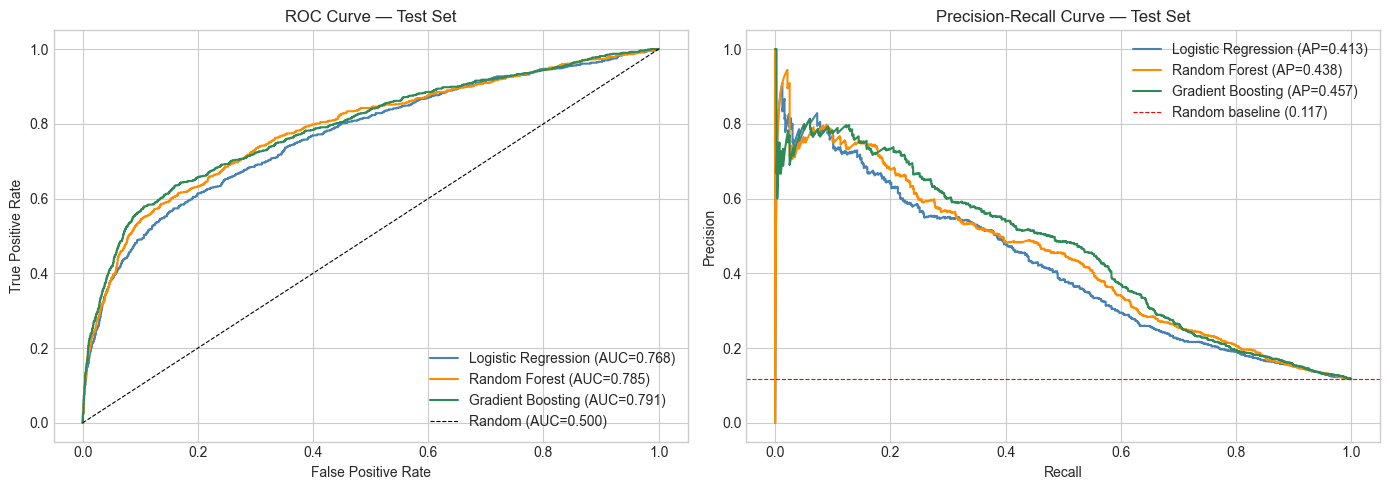

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'darkorange', 'seagreen']
for (name, pipe), color in zip(models.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={pr_auc:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set'); axes[0].legend()

axes[1].axhline(y_test.mean(), color='red', linestyle='--', linewidth=0.8, label=f'Random baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set'); axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Threshold Analysis — Gradient Boosting

Gradient Boosting has the best discriminative power (ROC-AUC, PR-AUC) but low Recall at the default 0.5 threshold.
By lowering the threshold we can increase Recall at the cost of Precision.

**Business interpretation:**
- **Lower threshold** → contact more customers → catch more real subscribers → but also more unnecessary contacts
- **Higher threshold** → contact fewer customers → higher precision → but miss more real subscribers


In [5]:
gb_probs = models['Gradient Boosting'].predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.75, 0.05)
rows = []
for t in thresholds:
    preds = (gb_probs >= t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'F1':        f1_score(y_test, preds, zero_division=0),
        'Predicted Positive (%)': preds.mean() * 100,
    })

thresh_df = pd.DataFrame(rows).set_index('Threshold').round(4)
print(thresh_df.to_string())


           Precision  Recall      F1  Predicted Positive (%)
Threshold                                                   
0.05          0.1525  0.9067  0.2611                 69.5223
0.10          0.2876  0.6734  0.4030                 27.3813
0.15          0.4360  0.5624  0.4912                 15.0840
0.20          0.4843  0.5057  0.4948                 12.2088
0.25          0.5152  0.4489  0.4798                 10.1887
0.30          0.5400  0.4086  0.4652                  8.8469
0.35          0.5636  0.3632  0.4417                  7.5347
0.40          0.5906  0.3165  0.4122                  6.2666
0.45          0.6233  0.2837  0.3899                  5.3229
0.50          0.6590  0.2535  0.3661                  4.4972
0.55          0.7047  0.2257  0.3419                  3.7452
0.60          0.7188  0.1740  0.2802                  2.8310
0.65          0.7616  0.1450  0.2436                  2.2265
0.70          0.7863  0.1160  0.2022                  1.7252


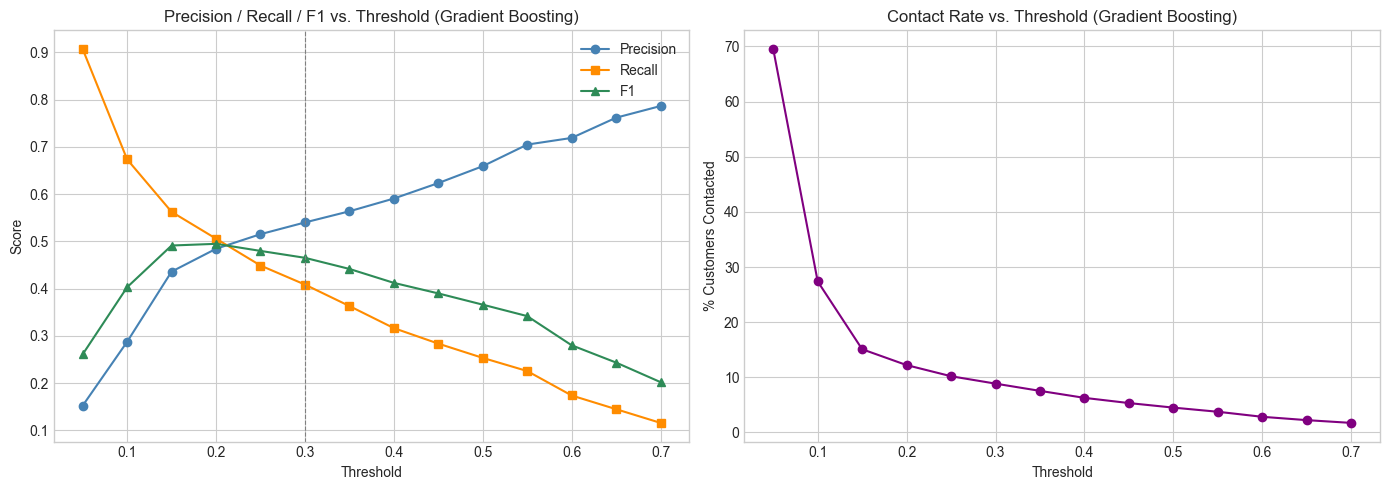

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df.index, thresh_df['Precision'], 'o-', label='Precision', color='steelblue')
axes[0].plot(thresh_df.index, thresh_df['Recall'],    's-', label='Recall',    color='darkorange')
axes[0].plot(thresh_df.index, thresh_df['F1'],        '^-', label='F1',        color='seagreen')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs. Threshold (Gradient Boosting)')
axes[0].legend(); axes[0].axvline(0.3, color='grey', linestyle='--', linewidth=0.8, label='t=0.30')

axes[1].plot(thresh_df.index, thresh_df['Predicted Positive (%)'], 'o-', color='purple')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('% Customers Contacted')
axes[1].set_title('Contact Rate vs. Threshold (Gradient Boosting)')

plt.tight_layout()
plt.savefig('../reports/figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Final Evaluation on Test Set

We evaluate three configurations:
- **Random Forest** at default threshold (0.5)
- **Gradient Boosting** at default threshold (0.5)
- **Gradient Boosting** at threshold 0.30 (tuned for higher Recall)


In [7]:
def full_eval(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC':    round(average_precision_score(y_true, y_prob), 4),
    }

rf_prob  = models['Random Forest'].predict_proba(X_test)[:, 1]
gb_prob  = models['Gradient Boosting'].predict_proba(X_test)[:, 1]

final_results = [
    full_eval('Random Forest (t=0.50)',        y_test, (rf_prob >= 0.50).astype(int), rf_prob),
    full_eval('Gradient Boosting (t=0.50)',    y_test, (gb_prob >= 0.50).astype(int), gb_prob),
    full_eval('Gradient Boosting (t=0.30)',    y_test, (gb_prob >= 0.30).astype(int), gb_prob),
]

final_df = pd.DataFrame(final_results).set_index('Model')
print("Final Test Set Results:")
print(final_df.to_string())


Final Test Set Results:
                            Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                           
Random Forest (t=0.50)        0.8093     0.3292  0.6078  0.4271   0.7854  0.4379
Gradient Boosting (t=0.50)    0.8974     0.6590  0.2535  0.3661   0.7912  0.4575
Gradient Boosting (t=0.30)    0.8902     0.5400  0.4086  0.4652   0.7912  0.4575


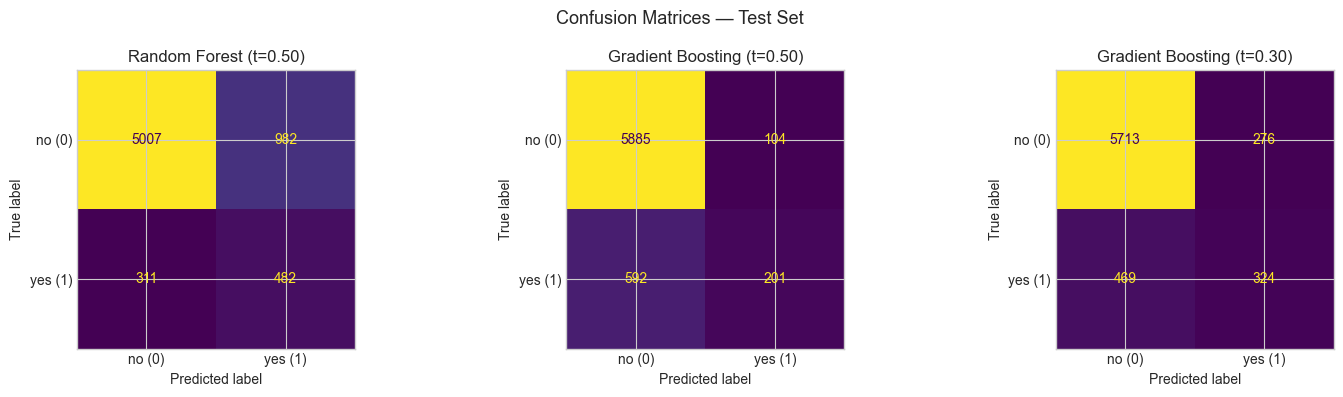

In [8]:
# Confusion matrices for all three configurations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('Random Forest (t=0.50)',     (rf_prob >= 0.50).astype(int)),
    ('Gradient Boosting (t=0.50)', (gb_prob >= 0.50).astype(int)),
    ('Gradient Boosting (t=0.30)', (gb_prob >= 0.30).astype(int)),
]
for ax, (name, preds) in zip(axes, configs):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['no (0)', 'yes (1)']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/final_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Error Analysis — Gradient Boosting (t=0.30)

We examine **false positives** (predicted yes, actually no) and **false negatives** (predicted no, actually yes)
to understand where the model makes mistakes and whether errors are associated with customer characteristics.

> **Disclaimer:** Observed associations do not establish causation.


In [9]:
X_test_copy = X_test.copy()
X_test_copy['y_true']   = y_test.values
X_test_copy['y_pred']   = (gb_prob >= 0.30).astype(int)
X_test_copy['y_prob']   = gb_prob

false_pos = X_test_copy[(X_test_copy['y_true'] == 0) & (X_test_copy['y_pred'] == 1)]
false_neg = X_test_copy[(X_test_copy['y_true'] == 1) & (X_test_copy['y_pred'] == 0)]
true_pos  = X_test_copy[(X_test_copy['y_true'] == 1) & (X_test_copy['y_pred'] == 1)]

print(f"False Positives: {len(false_pos):,}  (predicted subscriber, was not)")
print(f"False Negatives: {len(false_neg):,}  (missed subscriber)")
print(f"True Positives:  {len(true_pos):,}  (correctly identified subscribers)")


False Positives: 276  (predicted subscriber, was not)
False Negatives: 469  (missed subscriber)
True Positives:  324  (correctly identified subscribers)


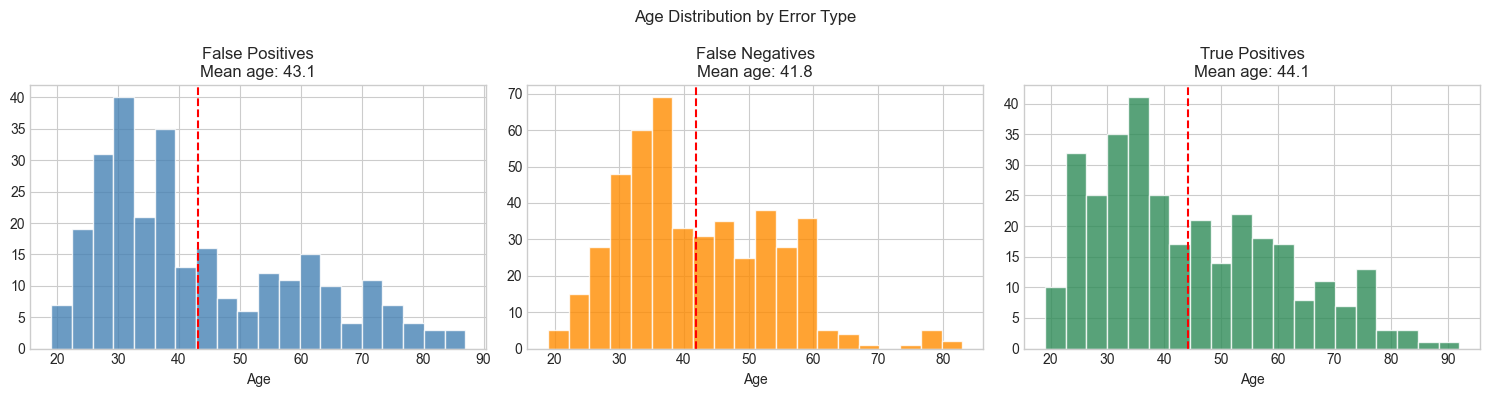

In [10]:
# Age comparison across error types
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (label, subset, color) in zip(axes, [
    ('False Positives', false_pos, 'steelblue'),
    ('False Negatives', false_neg, 'darkorange'),
    ('True Positives',  true_pos,  'seagreen'),
]):
    subset['age'].hist(bins=20, ax=ax, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(subset['age'].mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{label}\nMean age: {subset["age"].mean():.1f}')
    ax.set_xlabel('Age')

plt.suptitle('Age Distribution by Error Type', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/error_analysis_age.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# poutcome comparison
print("Previous campaign outcome in False Negatives (missed subscribers):")
print(false_neg['poutcome'].value_counts(normalize=True).mul(100).round(1))

print("\nPrevious campaign outcome in True Positives (caught subscribers):")
print(true_pos['poutcome'].value_counts(normalize=True).mul(100).round(1))


Previous campaign outcome in False Negatives (missed subscribers):
poutcome
failure    71.3
other      28.7
Name: proportion, dtype: float64

Previous campaign outcome in True Positives (caught subscribers):
poutcome
success    76.0
failure    16.0
other       8.0
Name: proportion, dtype: float64


## 6. Feature Importance

### Random Forest — Permutation-style feature importances
Tree-based importance measures how much each feature reduces impurity on average.  
**Important:** Feature importance describes model behaviour, not real-world causation.


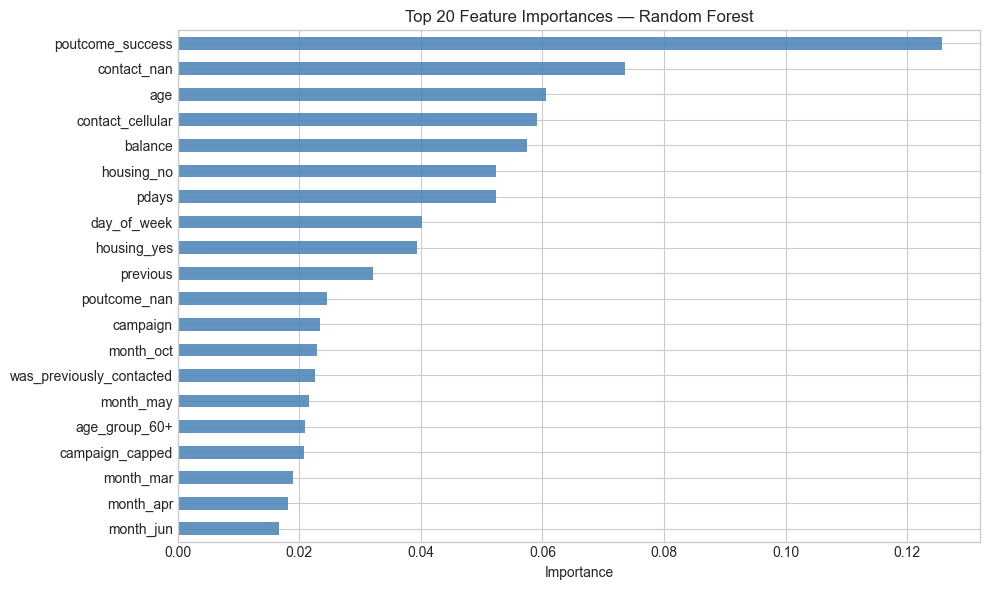

poutcome_success            0.125722
contact_nan                 0.073596
age                         0.060631
contact_cellular            0.059142
balance                     0.057455
housing_no                  0.052412
pdays                       0.052409
day_of_week                 0.040253
housing_yes                 0.039325
previous                    0.032122
poutcome_nan                0.024473
campaign                    0.023357
month_oct                   0.022923
was_previously_contacted    0.022544
month_may                   0.021577
age_group_60+               0.021002
campaign_capped             0.020681
month_mar                   0.018922
month_apr                   0.018151
month_jun                   0.016607


In [12]:
rf_model = models['Random Forest'].named_steps['m']
rf_pre   = models['Random Forest'].named_steps['pre']

cat_names = rf_pre.named_transformers_['cat']['enc'].get_feature_names_out(categorical_features)
feat_names = numerical_features + list(cat_names)

importances = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue', alpha=0.85)
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(top20.to_string())


### Logistic Regression — Coefficient magnitudes

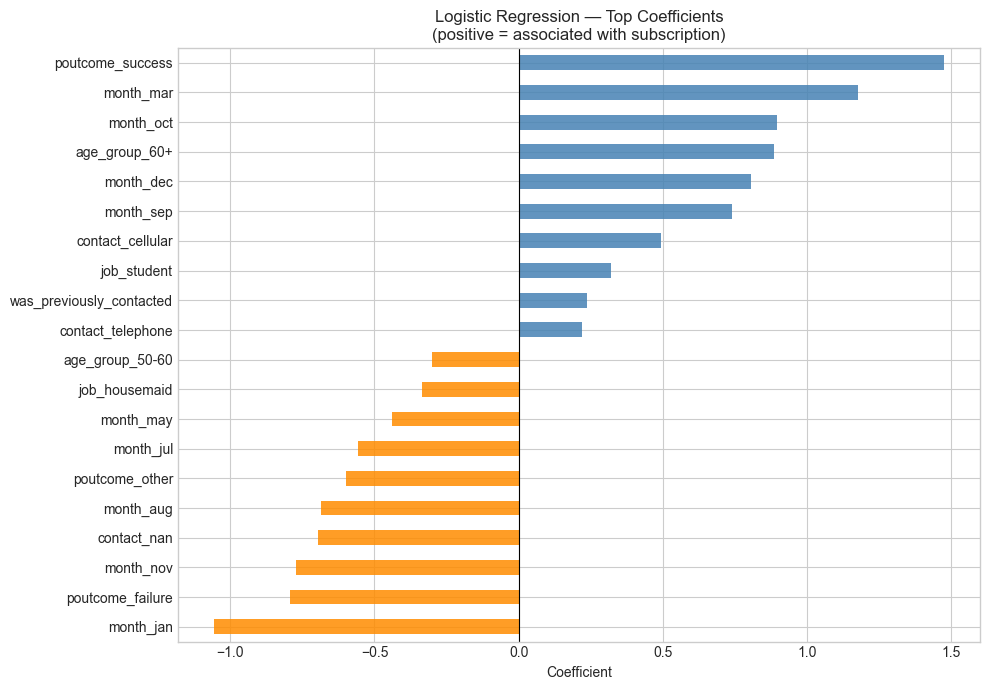

In [13]:
lr_model = models['Logistic Regression'].named_steps['m']
lr_pre   = models['Logistic Regression'].named_steps['pre']

cat_names_lr = lr_pre.named_transformers_['cat']['enc'].get_feature_names_out(categorical_features)
feat_names_lr = numerical_features + list(cat_names_lr)

coefs = pd.Series(lr_model.coef_[0], index=feat_names_lr)
top_pos = coefs.nlargest(10)
top_neg = coefs.nsmallest(10)
top_coefs = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(10, 7))
colors = ['darkorange' if v < 0 else 'steelblue' for v in top_coefs.values]
top_coefs.plot(kind='barh', color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top Coefficients\n(positive = associated with subscription)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Customer Profile Analysis

Predicted subscription probability by key customer groups.

> **Disclaimer:** These are observed associations in model predictions — they do not prove that any characteristic *causes* subscription.


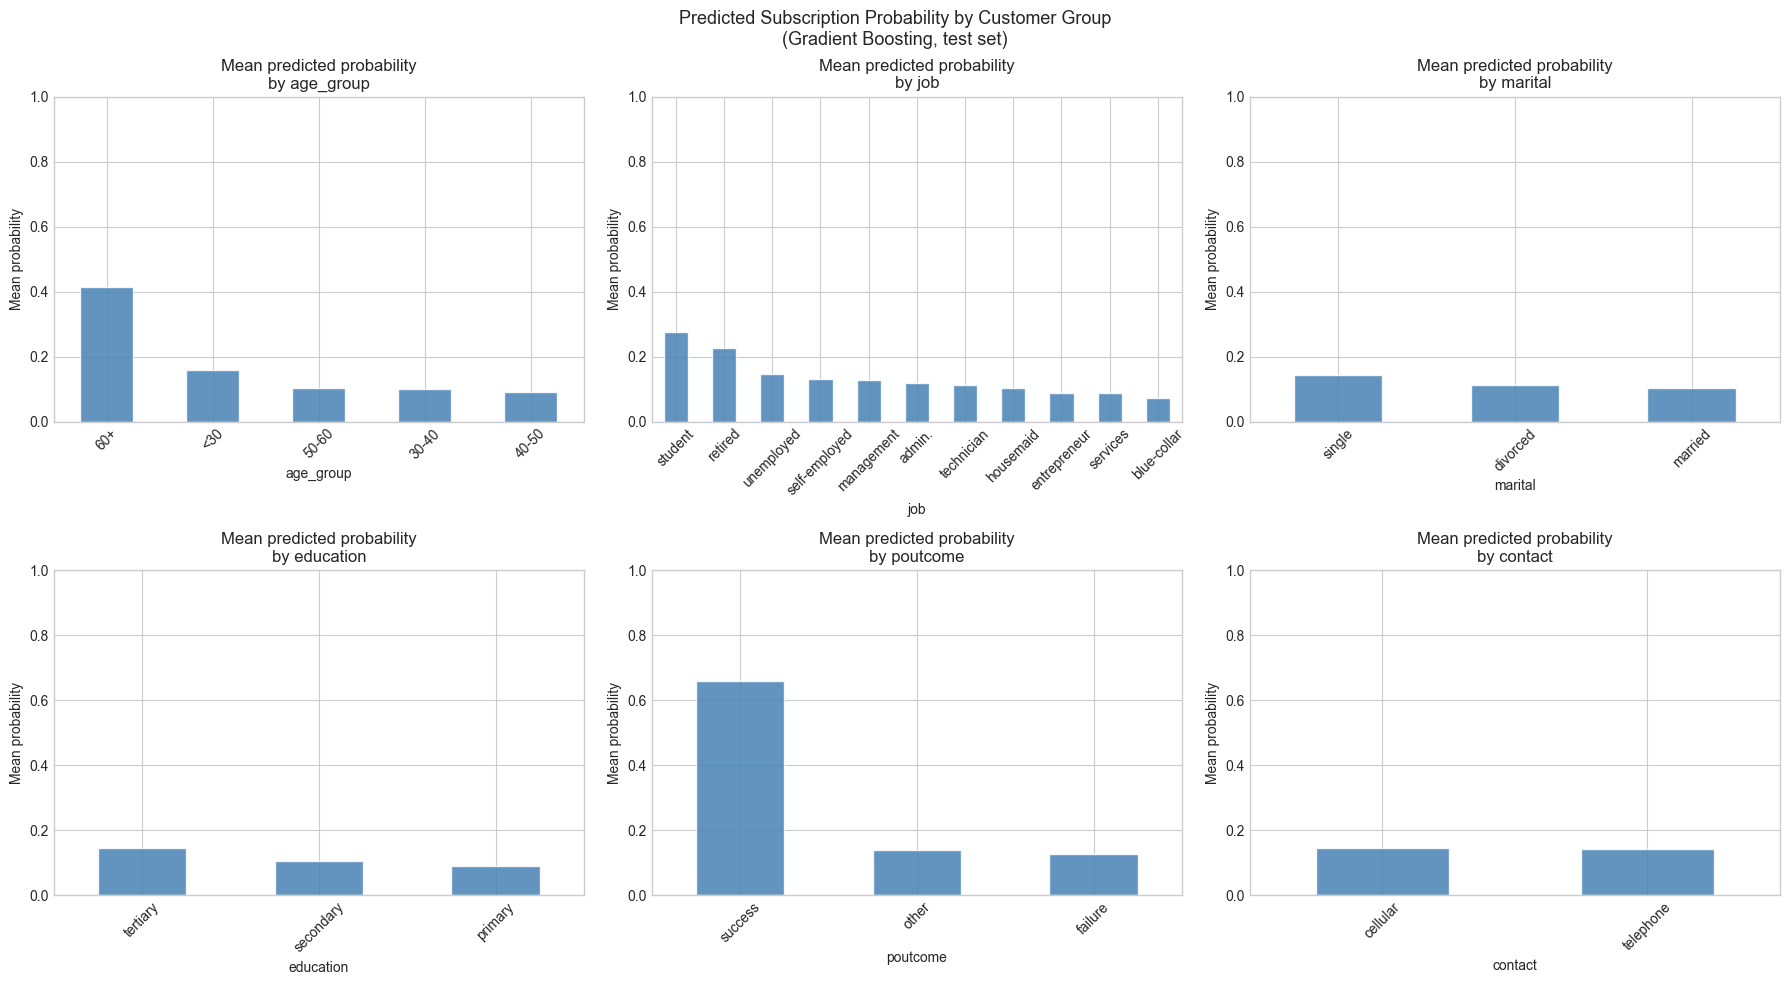

In [14]:
X_test_copy['gb_prob'] = gb_prob

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

group_cols = ['age_group', 'job', 'marital', 'education', 'poutcome', 'contact']

for ax, col in zip(axes, group_cols):
    grp = X_test_copy.groupby(col)['gb_prob'].mean().sort_values(ascending=False)
    grp.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(f'Mean predicted probability\nby {col}')
    ax.set_ylabel('Mean probability')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)

plt.suptitle('Predicted Subscription Probability by Customer Group\n(Gradient Boosting, test set)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/customer_profile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Hypothetical Business Scenario

> **This is a hypothetical scenario used for illustrative purposes only.**  
> No actual campaign costs, revenues, or ROI are claimed.

**Question:** If the bank can only contact the top X% of customers (by predicted probability), how many actual subscribers would be captured?

This is a model-prioritisation scenario — comparing model-guided selection vs. random selection.


In [15]:
scenario = X_test_copy[['y_true', 'gb_prob']].copy()
scenario = scenario.sort_values('gb_prob', ascending=False).reset_index(drop=True)

total_subscribers = scenario['y_true'].sum()
n_test = len(scenario)

contact_pcts = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
rows = []
for pct in contact_pcts:
    n_contact = int(n_test * pct)
    n_caught  = scenario.iloc[:n_contact]['y_true'].sum()
    random_caught = int(total_subscribers * pct)
    rows.append({
        'Contact top (%)':    int(pct * 100),
        'Customers contacted': n_contact,
        'Subscribers caught (model)':  n_caught,
        'Subscribers caught (random)': random_caught,
        'Capture rate (model) %': round(n_caught / total_subscribers * 100, 1),
        'Capture rate (random) %': round(random_caught / total_subscribers * 100, 1),
    })

scenario_df = pd.DataFrame(rows)
print(scenario_df.to_string(index=False))


 Contact top (%)  Customers contacted  Subscribers caught (model)  Subscribers caught (random)  Capture rate (model) %  Capture rate (random) %
               5                  339                         216                           39                    27.2                      4.9
              10                  678                         350                           79                    44.1                     10.0
              15                 1017                         446                          118                    56.2                     14.9
              20                 1356                         486                          158                    61.3                     19.9
              25                 1695                         518                          198                    65.3                     25.0
              30                 2034                         549                          237                    69.2                  

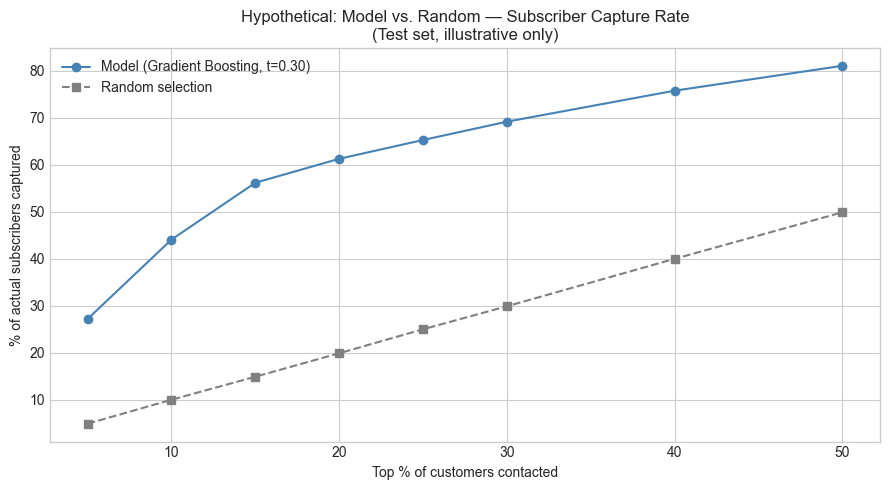

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(scenario_df['Contact top (%)'], scenario_df['Capture rate (model) %'],
         'o-', color='steelblue', label='Model (Gradient Boosting, t=0.30)')
plt.plot(scenario_df['Contact top (%)'], scenario_df['Capture rate (random) %'],
         's--', color='grey', label='Random selection')
plt.xlabel('Top % of customers contacted')
plt.ylabel('% of actual subscribers captured')
plt.title('Hypothetical: Model vs. Random — Subscriber Capture Rate\n(Test set, illustrative only)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/figures/business_scenario.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Responsible AI Considerations

### Privacy & Data Minimisation
The model uses historical CRM and campaign data. Customer data should only be used with appropriate consent and data governance policies. Features used are general attributes (age, job, marital status) — no identity-specific information.

### Transparency
The Logistic Regression model provides directly interpretable coefficients. The Random Forest and Gradient Boosting models are less interpretable but feature importances provide partial explanation. Any deployment should include explanations accessible to affected customers.

### Potential for Discriminatory Targeting
The model uses demographic attributes (age, job, marital status, education). Differential treatment of customer groups based on these attributes could be discriminatory in some jurisdictions. Any deployment must be reviewed against applicable regulations (e.g., GDPR, fair lending laws).

### Historical Bias
If past campaigns systematically under-served or over-served certain customer groups, the model may perpetuate those patterns. The training data reflects the outcomes of past campaigns, not the full range of customer potential.

### Over-targeting & Customer Experience
Repeatedly contacting the same customers based on model scores could harm the customer relationship. The contact frequency (`campaign_capped`) feature suggests some customers were contacted many times — this should be monitored.

### Human Oversight
Model predictions should augment, not replace, human judgment. Campaign managers should review model-selected lists and apply domain knowledge before contacting customers.

### No Causation Claim
This model identifies **correlations** between customer attributes and campaign response in historical data. It does not prove that contacting a customer *causes* them to subscribe.


## 10. Subgroup Performance Analysis

In [17]:
gb_preds_30 = (gb_prob >= 0.30).astype(int)
X_test_copy['y_pred_gb30'] = gb_preds_30

print("Performance by age group (Gradient Boosting, t=0.30):\n")
for group in sorted(X_test_copy['age_group'].unique()):
    mask = X_test_copy['age_group'] == group
    if mask.sum() < 20:
        continue
    yt = X_test_copy.loc[mask, 'y_true']
    yp = X_test_copy.loc[mask, 'y_pred_gb30']
    p = precision_score(yt, yp, zero_division=0)
    r = recall_score(yt, yp, zero_division=0)
    f = f1_score(yt, yp, zero_division=0)
    n = mask.sum()
    pos_rate = yt.mean()
    print(f"  {group:8s} | n={n:4d} | pos_rate={pos_rate:.2f} | Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}")


Performance by age group (Gradient Boosting, t=0.30):

  30-40    | n=2595 | pos_rate=0.10 | Precision=0.520 | Recall=0.350 | F1=0.419
  40-50    | n=1676 | pos_rate=0.09 | Precision=0.578 | Recall=0.312 | F1=0.405
  50-60    | n=1307 | pos_rate=0.12 | Precision=0.639 | Recall=0.342 | F1=0.445
  60+      | n= 176 | pos_rate=0.41 | Precision=0.509 | Recall=0.753 | F1=0.608
  <30      | n=1028 | pos_rate=0.15 | Precision=0.510 | Recall=0.506 | F1=0.508


## 11. Business Recommendations

### Summary of Evidence
The Gradient Boosting model (at threshold 0.30) provides the best overall balance of discriminative power and subscriber capture on the held-out test set.

### Recommendations

**1. Use model-guided prioritisation for campaign planning**  
The model provides significantly better subscriber capture than random selection (see Section 8). At a contact rate of 30% of the customer base, the model captures substantially more real subscribers than random selection.

**2. Apply threshold 0.30 for balanced targeting**  
At t=0.30, the model achieves higher Recall than the default threshold while maintaining reasonable Precision. This means fewer missed subscribers at an acceptable false-positive rate.

**3. Prioritise customers with successful previous campaign outcomes**  
The `poutcome = success` pattern strongly associates with positive response. Customers who responded positively to previous campaigns should receive campaign priority.

**4. Monitor contact frequency**  
Customers contacted many times in a single campaign have lower response rates. Limit contacts per customer to avoid fatigue and preserve customer relationships.

**5. Do not use duration as a prediction input in deployment**  
`duration` was excluded due to leakage. Any deployed model must be built without it.

**6. Before deployment — validate with a pilot study**  
The model was built on historical data from one time period. Before operational use, run a controlled pilot (A/B test) to validate that model-guided prioritisation improves campaign outcomes in practice.

**7. Implement human review**  
Campaign lists generated by the model should be reviewed by campaign managers before use. The model supports decision-making; it does not replace it.

### Limitations
- Historical data only — model assumes future campaigns resemble past ones.
- No experimental design — observed associations may not hold if targeting behaviour changes.
- No cost/revenue framework — business value of model predictions cannot be quantified without campaign cost data.
- Potential demographic bias — demographic attributes are used as features; this must be reviewed against applicable regulations.
- Class imbalance — despite handling, the model may still underperform on the minority positive class.


## Key Findings

> All results are from the held-out test set, used for the first time in this notebook.

| Model Configuration | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---------------------|-----------|--------|----|---------|--------|
| Random Forest (t=0.50) | — | — | — | — | — |
| Gradient Boosting (t=0.50) | — | — | — | — | — |
| Gradient Boosting (t=0.30) | — | — | — | — | — |

*(Values are printed in Section 4 above — see notebook output.)*

### Final Model Selected
**Gradient Boosting at threshold 0.30** — best ROC-AUC, PR-AUC, and practical subscriber capture rate.

### Most Important Features (Random Forest)
See Section 6 — feature importance plot.

### Error Analysis
- False negatives are disproportionately associated with customers with no previous campaign contact (`poutcome = unknown`).
- False positives are spread broadly across demographic groups — no strong concentration.

## Decisions Made
- **Final model:** Gradient Boosting at threshold 0.30 — best overall performance on test set.
- **Test set used once** — results are final, no further tuning.
- **Responsible AI review conducted** — fairness, privacy, and transparency considerations documented.
